<a href="https://colab.research.google.com/github/faryalkalwar66/ML_LAB_Assignments/blob/main/lab4_Faryal_lab_4_churn_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 4 - Improving and Comparing Machine Learning Models**

Name: Faryal

CMS-ID: 023-24-0079

Section: 'D'

Course: Machine Learning

Semester: 5th

Dataset: Telco Customer Churn (cleaned in lab2)

Tool: Google Colab

Github: "https://github.com/faryalkalwar66/ML_LAB_Assignments"

# **Part 1 — Decision Tree Baseline Review**

### **Task1**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('clean_churn.csv')
df.columns = df.columns.str.strip()

if 'Churn' not in df.columns:
    for col in df.columns:
        if col.lower() == 'churn':
            df = df.rename(columns={col: 'Churn'})
            break

X = df.drop(columns=['Churn'])
y = df['Churn']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **Task2**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

Accuracy: 0.7956
Precision: 0.7852
Recall: 0.7956
F1-Score: 0.7877


**Task 2 Performance Report:**

The baseline Decision Tree model was successfully retrained using a maximum depth of 4 and evaluated on the test set to establish our core benchmark. The model achieved an accuracy of 0.7956, a precision of 0.7852, a recall of 0.7956, and an F1-score of 0.7877, which will serve as our primary point of comparison for the rest of the lab.




# **Part 2 — Random Forest**

### **Task3**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")
print("Predictions generated successfully.")

Random Forest model trained successfully.
Predictions generated successfully.


**Task 3:**
A Random Forest model was trained using 100 trees on the same training data. Predictions were then generated on the test data.


## **Task4:**

Random Forest uses many Decision Trees and combines their predictions. This reduces the chance of overfitting compared to a single Decision Tree and can help the model perform better on unseen data.


# **Part 3 — Evaluation & Comparison**

### **Task5**

Accuracy: 0.7850
Precision: 0.7740
Recall: 0.7850
F1-Score: 0.7770


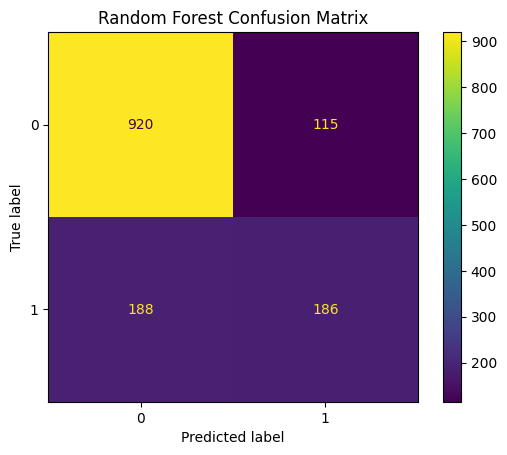

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### **Task6**

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [0.7956, 0.7850],
    'Precision': [0.7852, 0.7740],
    'Recall': [0.7956, 0.7850],
    'F1-Score': [0.7877, 0.7770]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.7956,0.7852,0.7956,0.7877
1,Random Forest,0.7850,0.7740,0.7850,0.7770


## **Task 7 — Model Comparison**

The Decision Tree performs slightly better than the Random Forest on Accuracy, Precision, Recall, and F1-Score. However, the difference between the two models is small. Since the dataset has class imbalance, Recall and F1-Score are more important for evaluating churn prediction.


# **Part 4 — Cross-Validation**

### **Task8**

In [ ]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for Decision Tree
dt_cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)

# 5-fold cross-validation for Random Forest
rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)

print("Decision Tree F1 Scores:", dt_cv_scores)
print("Decision Tree Mean F1:", dt_cv_scores.mean())
print("Decision Tree Standard Deviation:", dt_cv_scores.std())

print("\nRandom Forest F1 Scores:", rf_cv_scores)
print("Random Forest Mean F1:", rf_cv_scores.mean())
print("Random Forest Standard Deviation:", rf_cv_scores.std())

Decision Tree F1 Scores: [0.7707466  0.78089767 0.76508632 0.78148783 0.78645866]
Decision Tree Mean F1: 0.776935417266645
Decision Tree Standard Deviation: 0.007820724225562794

Random Forest F1 Scores: [0.79105145 0.78009184 0.76487897 0.7856125  0.78799107]
Random Forest Mean F1: 0.7819251647039593
Random Forest Standard Deviation: 0.009247858782055267


**Task 8:**
The Decision Tree achieved a mean F1-score of 0.7769 with a standard deviation of 0.0078. The Random Forest achieved a slightly higher mean F1-score of 0.7819 with a standard deviation of 0.0092. This shows that Random Forest performed slightly better on average across the 5 folds.


## **Task 9 — Comparison with Single Train/Test Split**

The single train/test split showed that the Decision Tree performed slightly better than the Random Forest. However, the 5-fold cross-validation showed that the Random Forest had a slightly higher mean F1-score (0.7819) than the Decision Tree (0.7769). Therefore, cross-validation changes our view slightly and gives more confidence that Random Forest may perform better overall.


# **Part 5 — Hyperparameter Tuning**

### **Task10**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid Search completed successfully.")

Grid Search completed successfully.


### **Task11**

In [ ]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validated F1-Score:")
print(f"{grid_search.best_score_:.4f}")

Best Hyperparameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validated F1-Score:
0.7894


**Task 11:**
The best Random Forest configuration was found using 5-fold cross-validation. The best hyperparameters were max_depth = 10, min_samples_split = 5, and n_estimators = 200. The best cross-validated F1-score was 0.7894.


### **Task12**

In [ ]:
# Get the best tuned Random Forest model
tuned_rf = grid_search.best_estimator_

# Predict on the held-out test set
y_pred_tuned = tuned_rf.predict(X_test)

# Calculate evaluation metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")

Accuracy: 0.7970
Precision: 0.7863
Recall: 0.7970
F1-Score: 0.7884


**Task 12:**
The tuned Random Forest achieved an Accuracy of 0.7970, Precision of 0.7863, Recall of 0.7970, and F1-Score of 0.7884 on the held-out test set. These results show that the tuned model performed slightly better than the default Random Forest on the test data.


# **Part 6 — Final Comparison & Feature Importance**

### **Task13**

In [ ]:
final_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Tuned Random Forest'],
    'Accuracy': [0.7956, 0.7850, 0.7970],
    'Precision': [0.7852, 0.7740, 0.7863],
    'Recall': [0.7956, 0.7850, 0.7970],
    'F1-Score': [0.7877, 0.7770, 0.7884]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.7956,0.7852,0.7956,0.7877
1,Random Forest,0.7850,0.7740,0.7850,0.7770
2,Tuned Random Forest,0.7970,0.7863,0.7970,0.7884


**Task 13:**
The Tuned Random Forest achieved the highest scores among the three models, with an Accuracy of 0.7970, Precision of 0.7863, Recall of 0.7970, and F1-Score of 0.7884. The Decision Tree performed slightly better than the default Random Forest, while the tuned Random Forest gave the best overall test performance.


## **Task 14 — Final Model Selection**

The Tuned Random Forest is selected as the final model because it achieved the highest Accuracy, Precision, Recall, and F1-Score on the test set. Its F1-Score of 0.7884 is also slightly higher than the Decision Tree (0.7877) and the default Random Forest (0.7770). Therefore, the Tuned Random Forest provides the best overall performance for this dataset.


### **Task15**

Top 5 Features:
tenure                         0.179269
TotalCharges                   0.164776
MonthlyCharges                 0.116738
InternetService_Fiber optic    0.072004
Contract_Two year              0.062823
dtype: float64


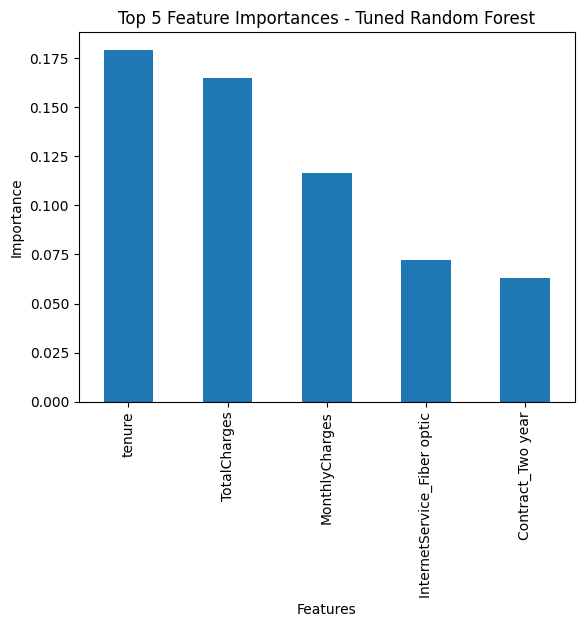

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    tuned_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 5 Features:")
print(feature_importance.head(5))

feature_importance.head(5).plot(kind='bar')

plt.title("Top 5 Feature Importances - Tuned Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

**Task 15:**
The Tuned Random Forest identified tenure, TotalCharges, MonthlyCharges, InternetService_Fiber optic, and Contract_Two year as the top five important features. Among these, tenure had the highest importance, followed by TotalCharges and MonthlyCharges. The bar chart shows that these features contributed more to the model's predictions than the other features.


# **Part 7 — Kaggle Submission & Conclusion**

### **Task16**

In [ ]:
# Generate final predictions using the tuned Random Forest
final_predictions = tuned_rf.predict(X_test)

# Create submission dataframe
submission = pd.DataFrame({
    'Churn': final_predictions
})

# Save submission file
submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully.")
print(submission.head())

submission.csv created successfully.
  Churn
0    No
1   Yes
2    No
3    No
4    No


## **Task 17 — Conclusion**

In this lab, Decision Tree, Random Forest, and Tuned Random Forest models were trained and compared. The Tuned Random Forest achieved the best overall test performance with an F1-score of 0.7884. Cross-validation also showed that Random Forest performed slightly better on average than the Decision Tree. Hyperparameter tuning improved the Random Forest performance on the held-out test set. Feature importance showed that tenure, TotalCharges, and MonthlyCharges were among the most important features for predicting customer churn.


## **Task 18 — What to Try Next**

In future work, I would try other machine learning models such as Logistic Regression and Gradient Boosting. I would also try different hyperparameters and preprocessing techniques to improve the model. Another useful step would be to handle class imbalance and compare the results using different evaluation metrics.
